### Load Libraries

### Load Data

In [1]:
import re, string, unicodedata
import contractions
from bs4 import BeautifulSoup

import numpy as np
import pandas as pd
import nltk

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem.wordnet import WordNetLemmatizer

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\codyd\AppData\Local\Temp\ipykernel_15116\3704726082.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\codyd\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv('Tweets.csv', index_col=0)
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns.")

There are 14640 rows and 14 columns.


In [3]:
df.sample(n=10)

,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
tweet_id,,,,,,,,,,,,,,
569540405676654592,negative,0.6800,Customer Service Issue,0.3500,Virgin America,NaN,jonesbasf,NaN,0,@VirginAmerica - Your site seems a little wonk...,NaN,2015-02-22 08:53:08 -0800,NaN,NaN
569864693998690304,positive,0.6675,NaN,NaN,Southwest,NaN,Kateria_Nicole,NaN,0,@SouthwestAir Just sent DM. Thanks for your a...,NaN,2015-02-23 06:21:45 -0800,"Atlanta, GA",Eastern Time (US & Canada)
569670634718023680,positive,1.0000,NaN,NaN,American,NaN,erina_jones,NaN,0,"@AmericanAir that's ok, thanks for letting me ...",NaN,2015-02-22 17:30:37 -0800,London,NaN
567807014388154368,negative,1.0000,Customer Service Issue,1.0000,Delta,NaN,bmk266,NaN,0,"@JetBlue tried calling multiple times, i just ...",NaN,2015-02-17 14:05:16 -0800,NaN,Quito
570115302991777792,negative,1.0000,Bad Flight,0.6736,United,NaN,747_TJ,NaN,0,@united It's too bad UA has had another unfo...,NaN,2015-02-23 22:57:35 -0800,NaN,NaN
569932197735604224,positive,0.6334,NaN,NaN,Southwest,NaN,lauravelasquez,NaN,0,@SouthwestAir Thanks for the quick reply! I t...,NaN,2015-02-23 10:49:59 -0800,"Denver, CO",Eastern Time (US & Canada)
570279720937529345,positive,1.0000,NaN,NaN,United,NaN,sundialtours,NaN,0,"@united ""Airport snow removal method #22...""\n...",NaN,2015-02-24 09:50:55 -0800,"Astoria, OR",Tijuana
569665707870285824,negative,1.0000,Lost Luggage,0.6946,American,NaN,jasminewallas,NaN,0,@AmericanAir delivered mom's delayed bag to th...,NaN,2015-02-22 17:11:03 -0800,NaN,NaN
569685746723848193,neutral,1.0000,NaN,NaN,Southwest,NaN,marlabainbridg1,NaN,0,@SouthwestAir I'm flying out of CUN tomorrow T...,NaN,2015-02-22 18:30:40 -0800,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14640 entries, 570306133677760513 to 569587140490866689
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   airline_sentiment             14640 non-null  object 
 1   airline_sentiment_confidence  14640 non-null  float64
 2   negativereason                9178 non-null   object 
 3   negativereason_confidence     10522 non-null  float64
 4   airline                       14640 non-null  object 
 5   airline_sentiment_gold        40 non-null     object 
 6   name                          14640 non-null  object 
 7   negativereason_gold           32 non-null     object 
 8   retweet_count                 14640 non-null  int64  
 9   text                          14640 non-null  object 
 10  tweet_coord                   1019 non-null   object 
 11  tweet_created                 14640 non-null  object 
 12  tweet_location                9907 

In [5]:
df.isnull().sum()

airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64

In [6]:
df.duplicated().sum()

36

In [7]:
df = df.drop_duplicates()

In [8]:
df.duplicated().sum()

0

In [9]:
df = df.drop(['airline_sentiment_gold', 'negativereason_gold'], axis=1)

## Exploratory Data Analysis

C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\codyd\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.g

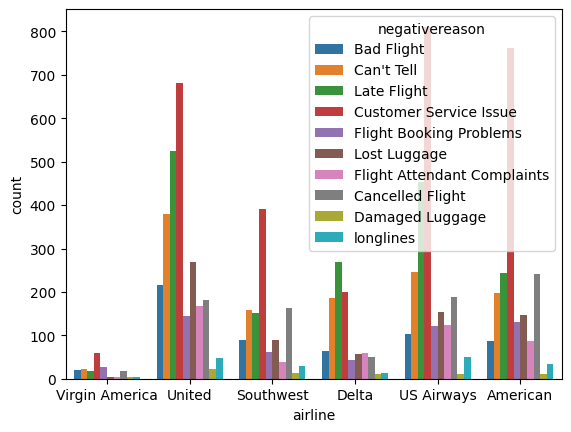

In [10]:
sns.countplot(data=df, x='airline', hue='negativereason');

In [11]:
df.negativereason.describe().T

count                       9159
unique                        10
top       Customer Service Issue
freq                        2904
Name: negativereason, dtype: object

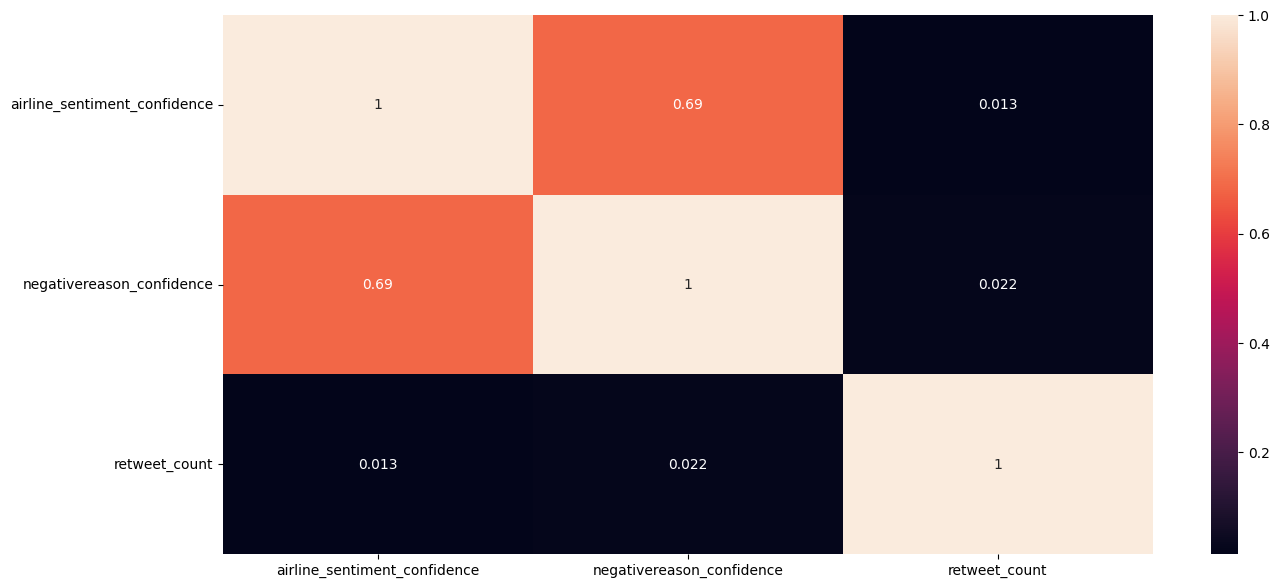

In [12]:
plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [13]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [26]:
customlist = ['not', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
"hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't", 'mustn',
"mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn',
"wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Set custom stop-word's list as not, couldn't etc. words matter in Sentiment, so not removing them from
# original data.

stopwords = list(set(stopwords) - set(customlist))

df['text'] = df.apply(lambda row: nltk.word_tokenize(row['text']), axis=1) # Tokenization of data

import wordcloud
def show_wordcloud(data, title):
    text = ' '.join(data['text'].astype(str).tolist()) # Converting text column into list
    stopwords = set(wordcloud.STOPWORDS) # instantiate the stopwords from wordcloud
    
    fig_wordcloud = wordcloud.WordCloud(stopwords=stopwords,background_color='white', # Setting the different parameter of stopwords
    colormap='viridis', width=800, height=600).generate(text)
    
    plt.figure(figsize=(14,11), frameon=True)
    plt.imshow(fig_wordcloud)
    plt.axis('off')
    plt.title(title, fontsize=30)
    plt.show()

TypeError: expected string or bytes-like object, got 'list'